# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?
2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?
3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?
4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?
5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?

1. SAX преобразует временной ряд в строку символов на основе агрегирования по отрезкам и квантилизации нормированных значений. SFA использует дискретное преобразование Фурье для получения коэффициентов, которые затем квантуются. SFA лучше работает с шумом, так как низкочастотные коэффициенты Фурье подавляют высокочастотный шум, в то время как SAX может быть более чувствителен к локальным выбросам.

2. BOSS строит гистограммы частот символов SFA из окон фиксированной длины, а затем применяет TF-IDF (term frequency – inverse document frequency) для взвешивания редко встречающихся подпоследовательностей. Это позволяет выделить дискриминативные паттерны и уменьшить влияние часто встречающихся, но неинформативных символов, улучшая качество классификации.

3. Shapelet — это подпоследовательность, которая наилучшим образом разделяет классы по расстоянию до неё (например, минимальное евклидово расстояние). ROCKET вместо поиска оптимальных шейплетов генерирует тысячи случайных сверточных ядер (с разной длиной, весами и расширением) и использует их выходы как признаки, что даёт высокую точность при линейной сложности и отсутствии этапа обучения формы ядер.

4. Catch22 обеспечивает сверхбыстрое вычисление (микросекунды на ряд) и интерпретируемость признаков (например, автокорреляция, нелинейность). Для небольших наборов данных или когда требуется объяснение решения, фиксированные признаки часто дают лучшее обобщение, чем переобучающаяся глубокая сеть. Кроме того, catch22 может использоваться как вход для традиционных моделей (например, случайного леса), которые работают на малом объёме данных.

5. 1D-CNN могут автоматически выделять локальные паттерны (формы, пики, тренды) и их комбинации на разных масштабах благодаря слоям свертки с различным размером ядра. Многоветвевые архитектуры (Inception Time) параллельно применяют несколько ядер разного размера, что позволяет одновременно захватывать как краткосрочные, так и долгосрочные зависимости, улучшая обобщение без увеличения глубины сети.



# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


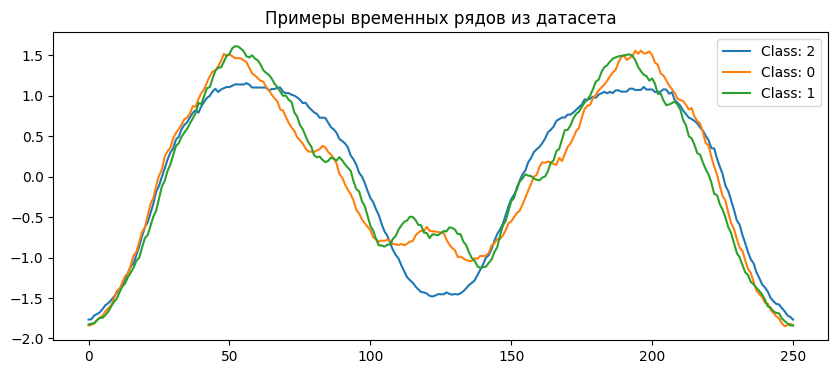

In [1]:
# Загрузка и подготовка данных
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [2]:
from sktime.classification.kernel_based import RocketClassifier
import time
from sklearn.metrics import accuracy_score

# Замер времени обучения
start_time = time.time()

# Инициализация и обучение классификатора
rocket = RocketClassifier(n_jobs=-1, random_state=42)
rocket.fit(X_train, y_train)

train_time = time.time() - start_time

# Предсказание и оценка качества
y_pred = rocket.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"RocketClassifier accuracy: {accuracy:.4f}")
print(f"Training time: {train_time:.4f} seconds")

RocketClassifier accuracy: 0.9375
Training time: 8.7145 seconds


### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [4]:
from sktime.classification.dictionary_based import ContractableBOSS
import time
from sklearn.metrics import accuracy_score

# Замер времени обучения
start_time = time.time()

# Инициализация и обучение классификатора
cboss = ContractableBOSS(n_jobs=-1, random_state=42)
cboss.fit(X_train, y_train)

train_time = time.time() - start_time

# Предсказание и оценка качества
y_pred = cboss.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"ContractableBOSS accuracy: {accuracy:.4f}")
print(f"Training time: {train_time:.4f} seconds")

C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\parallel.py:128: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


ContractableBOSS accuracy: 0.9531
Training time: 27.5146 seconds


ROCKET оказался быстрее

### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch). 
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

In [6]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        self.flatten = nn.Flatten()
        
        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

X_train shape: torch.Size([147, 1, 251])
Epoch 5/20, Loss: 0.8048
Epoch 10/20, Loss: 0.5590
Epoch 15/20, Loss: 0.3415
Epoch 20/20, Loss: 0.2331
Точность 1D-CNN: 0.8281


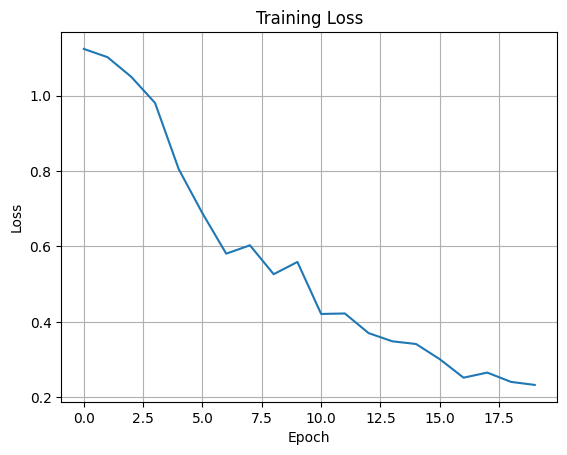

In [10]:
def to_2d(data):
    # data — список массивов или список списков
    return np.array([np.asarray(sample).flatten() for sample in data])

X_train_2d = to_2d(X_train)
X_test_2d = to_2d(X_test)

X_train_tensor = torch.tensor(X_train_2d, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_2d, dtype=torch.float32).unsqueeze(1)

# Метки
y_train_int = np.array(y_train, dtype=np.int64)
y_test_int = np.array(y_test, dtype=np.int64)
y_train_tensor = torch.tensor(y_train_int, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_int, dtype=torch.long)

print(f"X_train shape: {X_train_tensor.shape}")  # должно быть (n_samples, 1, length)

# DataLoader
batch_size = 16
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Инициализация модели
num_classes = len(np.unique(y_train_int))
model = Simple1DCNN(num_classes=num_classes)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение
num_epochs = 20
train_losses = []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

# Оценка на тестовой выборке
model.eval()
y_pred = []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_pred.extend(preds.cpu().numpy())

accuracy = accuracy_score(y_test_int, y_pred)
print(f"Точность 1D-CNN: {accuracy:.4f}")

# График потерь
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

Работает быстрее предыдущих